# Exploring fanta.db

`output/fanta.db` is a SQLite database built by `fanta.py merge` from every
Excel file you've downloaded. This notebook shows how to query it, with a
particular focus on the thing that makes it useful over the raw Excel
files: **the same player is linked by a stable `player_id` across seasons,
leagues, and granularities (season totals vs per-matchday votes)**, even
though fantacalcio.it's exports only ever give you a name string per row.

Tables you'll find (depending on what you've downloaded so far):

- `players` - one row per resolved player: `player_id`, `canonical_name`
- `stats` - Serie A season stats, one row per player per season
- `prices` - Euro Leghe quotazioni (price list), one row per player per season
- `votes` - Serie A matchday votes + bonus/malus events, one row per player per matchday

`player_id` is the join key across all of them. It's built from
fantacalcio.it's **own internal player id** - the `Id` column in
stats/prices and `Cod.` in votes turn out to be the exact same number for
the same player (confirmed by cross-checking real rows). That's a much
stronger join key than guessing from the name string, and it's what most
of this notebook actually relies on - see section 3 and the Notes at the
end.

In [1]:
import sqlite3
import pandas as pd

DB_PATH = "../output/fanta.db"
conn = sqlite3.connect(DB_PATH)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

## 1. What's actually in here

In [2]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,players
1,stats
2,votes
3,prices


In [3]:
for t in tables["name"]:
    cols = pd.read_sql(f"PRAGMA table_info({t})", conn)["name"].tolist()
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", conn)["n"][0]
    print(f"{t:10s} {n:6d} rows  columns: {cols}")

players      3801 rows  columns: ['player_id', 'canonical_name']
stats        4630 rows  columns: ['source_id', 'role', 'role_detail', 'name', 'team', 'price_current', 'price_initial', 'price_diff', 'price_current_mantra', 'price_initial_mantra', 'price_diff_mantra', 'market_value', 'market_value_mantra', 'file_type', 'league', 'season', 'source_file', 'raw__nazione', 'appearances', 'avg_vote', 'fantamedia', 'goals', 'goals_conceded', 'penalties_saved', 'penalties_taken', 'penalties_scored', 'penalties_missed', 'assists', 'yellow_cards', 'red_cards', 'own_goals', 'vote', 'raw__rf', 'raw__gdv', 'raw__gdp', 'vote_source', 'vote_provisional', 'matchday', 'player_id']


votes      234264 rows  columns: ['source_id', 'role', 'role_detail', 'name', 'team', 'price_current', 'price_initial', 'price_diff', 'price_current_mantra', 'price_initial_mantra', 'price_diff_mantra', 'market_value', 'market_value_mantra', 'file_type', 'league', 'season', 'source_file', 'raw__nazione', 'appearances', 'avg_vote', 'fantamedia', 'goals', 'goals_conceded', 'penalties_saved', 'penalties_taken', 'penalties_scored', 'penalties_missed', 'assists', 'yellow_cards', 'red_cards', 'own_goals', 'vote', 'raw__rf', 'raw__gdv', 'raw__gdp', 'vote_source', 'vote_provisional', 'matchday', 'player_id']
prices       8545 rows  columns: ['source_id', 'role', 'role_detail', 'name', 'team', 'price_current', 'price_initial', 'price_diff', 'price_current_mantra', 'price_initial_mantra', 'price_diff_mantra', 'market_value', 'market_value_mantra', 'file_type', 'league', 'season', 'source_file', 'raw__nazione', 'appearances', 'avg_vote', 'fantamedia', 'goals', 'goals_conceded', 'penalties_saved',

## 2. A basic query: top fantamedia this season

Nothing fancy yet - just SQL through pandas, same as any other SQLite db.

In [4]:
current_season = pd.read_sql("SELECT MAX(season) AS s FROM stats", conn)["s"][0]
print("current season:", current_season)

pd.read_sql(
    """
    SELECT name, team, role, appearances, avg_vote, fantamedia, goals, assists
    FROM stats
    WHERE season = ?
    ORDER BY fantamedia DESC
    LIMIT 10
    """,
    conn,
    params=[current_season],
)

current season: 2026-27


,name,team,role,appearances,avg_vote,fantamedia,goals,assists
0,Malen,Roma,A,5.0,7.10,10.60,6.0,0.0
1,Odenthal,Sassuolo,D,1.0,7.00,10.00,1.0,0.0
2,Varela G.,Monza,A,4.0,6.88,9.75,4.0,0.0
3,Moreira,Milan,C,3.0,6.67,9.67,3.0,0.0
4,Gatti,Juventus,D,1.0,7.00,9.50,1.0,0.0
5,Martinez L.,Inter,A,4.0,6.75,9.50,4.0,0.0
6,Zeballos,Monza,A,1.0,6.50,9.50,1.0,0.0
7,Zhegrova,Juventus,C,3.0,6.67,9.00,2.0,1.0
8,Raimondo,Frosinone,A,5.0,6.60,8.80,4.0,0.0
9,Kvernadze,Frosinone,A,5.0,6.90,8.80,3.0,1.0


## 3. Looking up a player_id by name

Every table stores the *original* name string from that particular file
(`stats.name`, `prices.name`, `votes.name`) plus the resolved `player_id`.
The `players` table holds one canonical name per id - the fullest-looking
variant seen so far (see `fantatool/merge.py::_maybe_upgrade_canonical`).

Two `player_id` formats show up:

- `FC<n>` - fantacalcio.it's own internal player id (`Id`/`Cod.` in the raw
  files), used whenever a row has one. This is the normal case.
- `NM<n>` - a locally-assigned id, used only as a fallback for the rare row
  with no usable source id. Fuzzy name-matching (`fantatool/names.py`)
  decides these, the same way *all* ids used to be assigned before the
  source-id discovery.

A small helper to search by (partial) name:

In [5]:
def find_player(name_substring):
    return pd.read_sql(
        "SELECT player_id, canonical_name FROM players WHERE canonical_name LIKE ?",
        conn,
        params=[f"%{name_substring}%"],
    )

find_player("Piccoli")

,player_id,canonical_name
0,FC4359,Piccoli


## 4. Cross-season timeline for one player

`stats` has one row per player per season. Group by `player_id` (not by
name - two players can share a surname) and sort by season to get a
career timeline, transfers included. `Piccoli` (Roberto Piccoli) is a good
example: a different Serie A club almost every year.

In [6]:
player_id = find_player("Piccoli").iloc[0]["player_id"]

pd.read_sql(
    """
    SELECT season, team, role, appearances, avg_vote, fantamedia, goals, assists
    FROM stats
    WHERE player_id = ?
    ORDER BY season
    """,
    conn,
    params=[player_id],
)

,season,team,role,appearances,avg_vote,fantamedia,goals,assists
0,2020-21,Spezia,A,14.0,6.07,7.14,5.0,0.0
1,2021-22,Genoa,A,8.0,5.69,6.06,1.0,0.0
2,2022-23,Empoli,A,16.0,5.84,6.22,2.0,0.0
3,2023-24,Lecce,A,32.0,6.02,6.41,5.0,0.0
4,2024-25,Cagliari,A,37.0,6.00,6.76,10.0,1.0
5,2025-26,Fiorentina,A,27.0,5.78,6.24,4.0,1.0
6,2026-27,Bologna,A,5.0,5.70,6.30,1.0,0.0


## 5. Cross-league linking: same player_id in `stats` and `prices`

`stats` only ever covers Serie A (that's all the `/stats/` endpoint
serves). `prices` covers Euro Leghe's much wider player pool (Serie A +
Premier League + La Liga + Bundesliga + Ligue 1, ~75 clubs). A player who's
in both tables under the same `player_id` proves the linking works
correctly across two completely different files - different columns,
different sheet layout, even a different `season_id` numbering scheme
(`stats` season_id=15 and `prices` season_id=103 are both "2020/21").

In [7]:
pd.read_sql(
    """
    SELECT s.season, s.team, s.fantamedia,
           pr.season AS prices_season, pr.price_current, pr.market_value
    FROM stats s
    JOIN prices pr ON pr.player_id = s.player_id AND pr.season = s.season
    WHERE s.player_id = ?
    ORDER BY s.season
    """,
    conn,
    params=[player_id],
)

,season,team,fantamedia,prices_season,price_current,market_value
0,2021-22,Genoa,6.06,2021-22,2.0,0.0
1,2025-26,Fiorentina,6.24,2025-26,9.0,13.0
2,2026-27,Bologna,6.30,2026-27,6.0,11.0


## 6. Matchday-level detail: `votes`

`stats` gives one row per player per *season*. `votes` is one row per
player per *matchday* - the finer-grained data behind those season
totals, plus per-match bonus/malus events (goals, assists, cards,
penalties). Same `player_id` join.

fantacalcio.it actually publishes three parallel vote sources per matchday
(`vote_source`: `Fantacalcio`/`Statistico`/`Italia`) - filtering to
`Fantacalcio` below picks the one actually used for official scoring.

In [8]:
pd.read_sql(
    """
    SELECT season, matchday, team, vote, vote_provisional, goals, assists, yellow_cards, red_cards
    FROM votes
    WHERE player_id = ? AND vote_source = 'Fantacalcio' AND season = '2022-23'
    ORDER BY matchday
    """,
    conn,
    params=[player_id],
)

,season,matchday,team,vote,vote_provisional,goals,assists,yellow_cards,red_cards
0,2022-23,1.0,Verona,6.0,0,0.0,0.0,0.0,0.0
1,2022-23,8.0,Verona,5.5,0,0.0,0.0,0.0,0.0
2,2022-23,10.0,Verona,6.0,0,0.0,0.0,0.0,0.0
3,2022-23,11.0,Verona,6.0,0,0.0,0.0,0.0,0.0
4,2022-23,17.0,Verona,6.0,0,0.0,0.0,0.0,0.0
5,2022-23,18.0,Verona,6.0,1,0.0,0.0,0.0,0.0
6,2022-23,20.0,Verona,6.0,1,0.0,0.0,0.0,0.0
7,2022-23,21.0,Empoli,6.0,0,0.0,0.0,0.0,0.0
8,2022-23,22.0,Empoli,6.5,0,0.0,0.0,0.0,0.0
9,2022-23,23.0,Empoli,6.0,1,0.0,0.0,0.0,0.0


## 7. Sanity check: does per-matchday data agree with the season totals?

`stats.avg_vote` is fantacalcio's own season-level average. Recomputing it
from the raw per-matchday `votes` rows should land close to the same
number - a good check that the matchday data and the season data (two
completely separate downloads) are actually describing the same player.

In [9]:
check = pd.read_sql(
    """
    SELECT s.season, s.avg_vote AS stats_avg_vote,
           ROUND(AVG(v.vote), 2) AS recomputed_from_votes,
           COUNT(v.vote) AS matchdays_with_a_vote
    FROM stats s
    JOIN votes v ON v.player_id = s.player_id AND v.season = s.season
    WHERE s.player_id = ? AND v.vote_source = 'Fantacalcio' AND v.vote IS NOT NULL
    GROUP BY s.season
    ORDER BY s.season
    """,
    conn,
    params=[player_id],
)
check

,season,stats_avg_vote,recomputed_from_votes,matchdays_with_a_vote
0,2020-21,6.07,6.05,20
1,2021-22,5.69,5.85,17
2,2022-23,5.84,5.88,20
3,2023-24,6.02,6.01,37
4,2024-25,6.00,6.00,37
5,2025-26,5.78,5.81,32
6,2026-27,5.70,5.70,5


## 8. A generic "full career" view

Stats, prices and votes have different columns and (for votes) a finer
granularity, so a straight `UNION` needs a bit of reshaping. This builds
one tidy season-level timeline combining all three (votes aggregated up
to season level to match), tagged by source table - reusable for any
`player_id`.

In [10]:
def career(player_id, conn=conn):
    stats = pd.read_sql(
        "SELECT season, league, team, appearances, avg_vote, fantamedia, goals, assists "
        "FROM stats WHERE player_id = ?",
        conn, params=[player_id],
    )
    stats["source"] = "stats"

    prices = pd.read_sql(
        "SELECT season, league, team, price_current, market_value "
        "FROM prices WHERE player_id = ?",
        conn, params=[player_id],
    )
    prices["source"] = "prices"

    votes = pd.read_sql(
        """
        SELECT season, league,
               COUNT(*) AS appearances, ROUND(AVG(vote), 2) AS avg_vote,
               SUM(goals) AS goals, SUM(assists) AS assists
        FROM votes
        WHERE player_id = ? AND vote_source = 'Fantacalcio' AND vote IS NOT NULL
        GROUP BY season
        """,
        conn, params=[player_id],
    )
    votes["source"] = "votes (aggregated per season)"

    combined = pd.concat([stats, prices, votes], ignore_index=True, sort=False)
    return combined.sort_values(["season", "source"]).reset_index(drop=True)

career(player_id)

,season,league,team,appearances,avg_vote,fantamedia,goals,assists,source,price_current,market_value
0,2020-21,Serie A,Spezia,14.0,6.07,7.14,5.0,0.0,stats,NaN,NaN
1,2020-21,Serie A,NaN,20.0,6.05,NaN,5.0,0.0,votes (aggregated per season),NaN,NaN
2,2021-22,Euroleghe,Atalanta,NaN,NaN,NaN,NaN,NaN,prices,2.0,0.0
3,2021-22,Serie A,Genoa,8.0,5.69,6.06,1.0,0.0,stats,NaN,NaN
4,2021-22,Serie A,NaN,17.0,5.85,NaN,1.0,0.0,votes (aggregated per season),NaN,NaN
5,2022-23,Serie A,Empoli,16.0,5.84,6.22,2.0,0.0,stats,NaN,NaN
6,2022-23,Serie A,NaN,20.0,5.88,NaN,2.0,0.0,votes (aggregated per season),NaN,NaN
7,2023-24,Serie A,Lecce,32.0,6.02,6.41,5.0,0.0,stats,NaN,NaN
8,2023-24,Serie A,NaN,37.0,6.01,NaN,4.0,0.0,votes (aggregated per season),NaN,NaN
9,2024-25,Serie A,Cagliari,37.0,6.00,6.76,10.0,1.0,stats,NaN,NaN


## 9. Fantamedia trend across seasons

A quick plot to sanity-check the linking visually - a smooth, plausible
trend line across years is a good sign the `player_id` grouping is
actually tracking one real person and not an accidental merge of two.

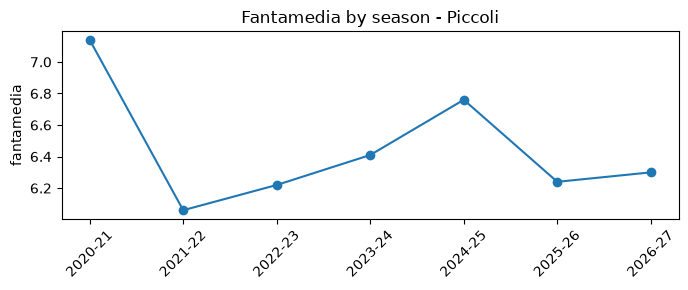

In [11]:
import matplotlib.pyplot as plt

hist = pd.read_sql(
    "SELECT season, fantamedia FROM stats WHERE player_id = ? ORDER BY season",
    conn, params=[player_id],
)
plt.figure(figsize=(7, 3))
plt.plot(hist["season"], hist["fantamedia"], marker="o")
plt.title(f"Fantamedia by season - {find_player('Piccoli').iloc[0]['canonical_name']}")
plt.ylabel("fantamedia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. When linking is *not* confident: needs_review.csv

Even with an exact source id, matching isn't blindly trusted: whenever a
`player_id` shows up with a name that doesn't plausibly resemble the name
already on file for it, that's flagged rather than silently accepted -
either fantacalcio changed how they display a player's name between
seasons (harmless), or, rarer, an old id got reused for a different real
person (matters). The same row repeating across many matchday/season
files collapses into one entry with an `occurrences` count.

Rows with no usable source id at all fall back to pure name-matching
(`fantatool/names.py`) and can also land here as `close_alternative_candidate_no_source_id`.

In [12]:
import pandas as pd

needs_review = pd.read_csv("../output/needs_review.csv")
needs_review

,source_file,raw_name,normalized_name,assigned_player_id,match_score,ambiguous_with,reason,occurrences
0,prices_2025_26.xlsx,Partey,partey,FC2683,0.167,existing_canonical_name:Thomas,source_id_name_mismatch,1
1,prices_2025_26.xlsx,Ezzalzouli,ezzalzouli,FC5736,0.353,existing_canonical_name:Ez Abde,source_id_name_mismatch,1
2,stats_2022_23.xlsx,Tressoldi,tressoldi,FC5747,0.154,existing_canonical_name:Ruan,source_id_name_mismatch,1
3,stats_2023_24.xlsx,Martin,martin,FC2593,0.462,existing_canonical_name:Caricol,source_id_name_mismatch,277
4,votes_2021_22_g21.xlsx,Ruan,ruan,FC5747,0.154,existing_canonical_name:Tressoldi,source_id_name_mismatch,99


A concrete look at one flagged id - same `player_id`, name changes
depending on which season's file it came from:

In [13]:
flagged_id = needs_review.iloc[0]["assigned_player_id"]

pd.read_sql(
    """
    SELECT DISTINCT source_file, name, team, season FROM stats WHERE player_id = ?
    UNION
    SELECT DISTINCT source_file, name, team, season FROM prices WHERE player_id = ?
    ORDER BY season
    """,
    conn,
    params=[flagged_id, flagged_id],
)

,source_file,name,team,season
0,prices_2017_18.xlsx,Thomas,Atletico Madrid,2017-18
1,prices_2018_19.xlsx,Thomas,Atletico Madrid,2018-19
2,prices_2019_20.xlsx,Thomas,Atletico Madrid,2019-20
3,prices_2020_21.xlsx,Thomas,Arsenal,2020-21
4,prices_2021_22.xlsx,Thomas,Arsenal,2021-22
5,prices_2022_23.xlsx,Thomas,Arsenal,2022-23
6,prices_2023_24.xlsx,Thomas,Arsenal,2023-24
7,prices_2024_25.xlsx,Thomas,Arsenal,2024-25
8,prices_2025_26.xlsx,Partey,Villarreal,2025-26


## 11. The data loader: all matches for one player

Everything above was hand-written SQL for exploring the data. The actual
reusable building block lives in `fantatool/loader.py` -
`player_matches(conn, player)` - one row per matchday for a given player
(by name or `player_id`), with season/league/matchday plus vote and every
bonus/malus event, sorted chronologically. This is meant to be the first
brick of a data pipeline (e.g. feeding a model) - import it from your own
scripts the same way this cell does.

In [14]:
import sys
sys.path.insert(0, "..")
from fantatool.loader import player_matches, find_player_id

matches = player_matches(conn, "Piccoli")
print(matches.shape, "- one row per matchday, chronological")
matches.head(10)

(168, 15) - one row per matchday, chronological


,season,league,matchday,team,role,vote,vote_provisional,goals,assists,yellow_cards,red_cards,own_goals,penalties_scored,penalties_missed,penalties_saved
0,2020-21,Serie A,3,Spezia,A,5.0,0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
1,2020-21,Serie A,4,Spezia,A,5.0,0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
2,2020-21,Serie A,5,Spezia,A,6.0,1,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
3,2020-21,Serie A,9,Spezia,A,6.5,0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
4,2020-21,Serie A,10,Spezia,A,6.0,1,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
5,2020-21,Serie A,11,Spezia,A,5.0,0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
6,2020-21,Serie A,13,Spezia,A,6.5,0,1.0,0.0,0.0,0.0,0.0,None,0.0,0.0
7,2020-21,Serie A,14,Spezia,A,6.0,1,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
8,2020-21,Serie A,15,Spezia,A,6.0,0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0
9,2020-21,Serie A,17,Spezia,A,6.0,1,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0


`player` also accepts a `player_id` directly (skip the name lookup once
you know it), and an ambiguous name raises rather than guessing:

In [15]:
print(find_player_id(conn, player_id))  # player_id from section 4, same result either way

try:
    player_matches(conn, "Martinez")
except ValueError as e:
    print("raises on ambiguous name:", e)

FC4359
raises on ambiguous name: 'Martinez' is ambiguous, matches: Martinez I. (FC2613), Martinez J. (FC4157), Martinez E. (FC4738), Martinez L. (FC2764), Martinez Quarta (FC5323), Martinez Jo. (FC5116), Martinez Lis. (FC5965) - pass one of those player_ids instead


## Notes

- `player_id` = `FC<n>` is **deterministic**, built directly from
  fantacalcio.it's own internal player id - it does not depend on
  processing order, so unlike a locally-invented counter it stays the same
  across repeated `merge` runs as you download more data. Safe to hardcode
  in your own notes/code if you want. The `NM<n>` fallback ids (no source
  id available) are the exception - those *can* shift between runs, so
  look those up by name each time rather than hardcoding them.
- Identity resolution lives in `fantatool/merge.py::_resolve_players`
  (source-id path first, `fantatool/names.py` fuzzy matching as fallback).
- Votes files are parsed by `fantatool/merge.py::_parse_votes_workbook` -
  worth a look if you want to understand the raw file's per-team-block
  layout (it's not a flat table, unlike stats/prices).
- Reusable query helpers (not just this notebook's inline SQL) belong in
  `fantatool/loader.py` - add the next data-loader building block there.